# Proyek Analisis Data: Bike-Sharing Dataset

- **Nama:** Riana Shofiatul Khoeriyah
- **Email Aktif:** rianashofiatulkhoeriyah24@gmail.com
- **ID Dicoding:** riana_sk


Pada proyek analisis data ini, akan mengeksplorasi dataset **Capital Bikeshare** dari Washington D.C. untuk memahami dinamika permintaan penyewaan sepeda publik selama periode 2011–2012. Pendekatan yang digunakan bersifat eksploratif dan eksplanatif sehingga tidak hanya melihat angka, tetapi membedah *mengapa* dan *kapan* orang memilih menyewa sepeda.

Melalui dataset ini, akan mencoba memahami:

- Bagaimana faktor eksternal seperti cuaca, musim, dan waktu hari memengaruhi keputusan pengguna untuk menyewa sepeda.
- Perbedaan perilaku antara pengguna kasual (rekreasi) dan pengguna terdaftar (komuter) yang dapat memberikan insight strategis bagi pengelola sistem bike-sharing.
- Kombinasi kondisi temporal dan lingkungan yang paling dan paling tidak menguntungkan bagi operasional bisnis.

Di akhir analisis, diharapkan mampu:

- Melakukan analisis eksploratif (EDA) secara mendalam untuk menemukan pola tersembunyi dalam data *time-series* penyewaan sepeda.
- Mengidentifikasi faktor-faktor lingkungan dan temporal yang paling signifikan memengaruhi permintaan penyewaan.
- Membangun *dashboard* interaktif menggunakan Streamlit untuk memvisualisasikan temuan kepada pemangku kepentingan.
- Memberikan rekomendasi berbasis data untuk optimalisasi operasional layanan *bike-sharing*.

**Sumber data:** [Bike Sharing Dataset](https://drive.google.com/file/d/1RaBmV6Q6FYWU4HWZs80Suqd7KQC34diQ/view)

## Menentukan Pertanyaan Bisnis

**Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca terhadap rata-rata jumlah penyewaan sepeda harian di Washington D.C. selama periode 2011–2012?

**Pertanyaan 2:** Pada jam berapakah rata-rata penyewaan sepeda mencapai puncaknya pada hari kerja dibandingkan dengan akhir pekan di Washington D.C. selama periode 2011–2012?


## Import Library/Packages yang Digunakan

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Data Wrangling

### Gathering Data

Langkah pertama adalah memuat kedua dataset ke dalam *environment* notebook. Dataset terdiri dari dua file CSV:
- `day.csv` — berisi data agregat penyewaan harian selama 731 hari (2011–2012).
- `hour.csv` — berisi data yang sama namun dipecah per jam, menghasilkan 17.379 baris data.

Kita akan melihat beberapa baris pertama dari masing-masing dataset untuk mendapatkan gambaran umum mengenai fitur-fitur (kolom) yang tersedia.

In [24]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
# Load dataset
path = '/content/drive/MyDrive/Submission_BFAD_Riana Shofiatul Khoeriyah/Bike-sharing-dataset'

df_list = []
for file in sorted(os.listdir(path)):
    if file.endswith('.csv'):
        df_list.append(pd.read_csv(os.path.join(path, file)))
        print(f"{file}")

air_quality_df = pd.concat(df_list, ignore_index=True)
print(f"\nTotal: {air_quality_df.shape[0]:,} rows × {air_quality_df.shape[1]} column")

day.csv
hour.csv

Total: 18,110 rows × 17 column


In [26]:
df_day  = pd.read_csv(os.path.join(path, 'day.csv'))
df_hour = pd.read_csv(os.path.join(path, 'hour.csv'))

print(f'Dataset Harian  : {df_day.shape[0]:,} baris, {df_day.shape[1]} kolom')
print(f'Dataset Per Jam : {df_hour.shape[0]:,} baris, {df_hour.shape[1]} kolom')

Dataset Harian  : 731 baris, 16 kolom
Dataset Per Jam : 17,379 baris, 17 kolom


In [27]:
df_day

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


In [28]:
df_hour

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


**Insight:** Langkah pertama adalah memuat kedua dataset ke dalam environment notebook. Dari hasil pemuatan, diperoleh df_day yang berisi 731 baris dan 16 kolom, serta df_hour yang berisi 17.379 baris dan 17 kolom. Perbedaan jumlah kolom antara keduanya disebabkan oleh keberadaan kolom hr pada df_hour yang merepresentasikan jam dalam sehari (0–23). Kedua dataset mencakup periode yang sama, yaitu dari 1 Januari 2011 hingga 31 Desember 2012.

### Assessing Data

Setelah data berhasil dikumpulkan, langkah selanjutnya adalah melakukan penilaian (*assessing*) untuk mengidentifikasi masalah kualitas dalam dataset. Pemeriksaan ini mencakup aspek-aspek berikut:

1. **Pemeriksaan Tipe Data.** Memastikan setiap kolom memiliki tipe data yang sesuai, misalnya kolom `dteday` harus bertipe `datetime` bukan `object`, serta kolom-kolom kategorikal seperti `season`, `weathersit`, dan `workingday` perlu diverifikasi agar tidak salah diinterpretasi sebagai nilai numerik kontinu.

2. **Pemeriksaan Missing Values.** Mengecek keberadaan nilai yang hilang (*null*/NaN) di setiap kolom. Dalam konteks dataset ini, nilai kosong pada kolom seperti `temp`, `hum`, atau `windspeed` dapat memengaruhi akurasi analisis korelasi antara faktor cuaca dan jumlah penyewaan sepeda.

3. **Pemeriksaan Data Duplikat.** Mengidentifikasi apakah terdapat baris data yang berulang secara identik. Pada dataset penyewaan sepeda yang bersifat *time-series*, duplikasi pada kolom `dteday` (untuk `day.csv`) atau kombinasi `dteday` dan `hr` (untuk `hour.csv`) dapat mengindikasikan adanya kesalahan pencatatan yang berpotensi mendistorsi analisis tren.

4. **Ringkasan Parameter Statistik.** Melihat distribusi data melalui ringkasan statistik seperti *mean*, *median*, *min*, *max*, dan kuartil pada kolom-kolom utama seperti `cnt`, `casual`, `registered`, `temp`, `hum`, dan `windspeed` untuk mendeteksi adanya anomali atau nilai ekstrem (*outliers*).

In [29]:
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


**Inkonsistensi Tipe Data:**

- `dteday`: Kolom ini bertipe `object` (string). Seharusnya bertipe `datetime` agar dapat digunakan dalam analisis berbasis waktu seperti pengelompokan per bulan dan perhitungan tren musiman.

**Ringkasan Struktur Data — `day.csv`:**
- Dataset terdiri dari **731 entri** dan **16 kolom**.
- Komposisi tipe data: `float64` (4 kolom), `int64` (11 kolom), `object` (1 kolom).
- Semua kolom memiliki **731 non-null values**, artinya tidak ada missing values pada tahap ini.

In [30]:
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


**Ringkasan Struktur Data — `hour.csv`:**
- Dataset terdiri dari **17.379 entri** dan **17 kolom** (sama seperti `day.csv` ditambah kolom `hr` untuk jam dalam sehari).
- Masalah tipe data yang sama ditemukan pada kolom `dteday` yang masih bertipe `object`.

In [31]:
print('Missing Values — day.csv')
print(df_day.isnull().sum())

Missing Values — day.csv
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [32]:
print('Missing Values — hour.csv')
print(df_hour.isnull().sum())

Missing Values — hour.csv
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


**Tidak ditemukan missing values** pada kedua dataset. Seluruh kolom memiliki jumlah nilai yang lengkap sesuai jumlah baris masing-masing. Ini menunjukkan bahwa proses pengumpulan data historis dari sistem Capital Bikeshare telah dilakukan dengan sangat baik dan tidak ada periode waktu yang tidak tercatat.

In [33]:
print(f'Duplikat day.csv  : {df_day.duplicated().sum()}')
print(f'Duplikat hour.csv : {df_hour.duplicated().sum()}')

Duplikat day.csv  : 0
Duplikat hour.csv : 0


**Tidak ditemukan data duplikat** pada kedua dataset. Setiap baris merepresentasikan periode waktu yang unik — satu hari untuk `day.csv` dan satu jam untuk `hour.csv`. Integritas data *time-series* terjaga dengan baik.

In [34]:
df_day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Indikasi Nilai Ternormalisasi (Perlu Denormalisasi):**

Berdasarkan statistik deskriptif, ditemukan beberapa kolom yang nilainya berada dalam rentang 0–1, menandakan bahwa nilai-nilai tersebut telah dinormalisasi oleh pemilik dataset:

- `temp`: Rentang 0.059 – 0.862, merupakan suhu yang dinormalisasi (nilai asli dalam °C, dibagi 41).
- `atemp`: Rentang 0.079 – 0.840, merupakan suhu terasa yang dinormalisasi (dibagi 50).
- `hum`: Rentang 0.000 – 0.972, merupakan kelembaban yang dinormalisasi (persentase 0–100%, dibagi 100).
- `windspeed`: Rentang 0.022 – 0.507, merupakan kecepatan angin yang dinormalisasi (dibagi 67).

**Sebaran Nilai Target:**

- `cnt` (total penyewaan): Rata-rata **4.504 penyewaan/hari**, dengan standar deviasi 1.937 yang cukup besar — menunjukkan variasi permintaan yang signifikan antar hari.
- `casual` vs `registered`: Pengguna terdaftar mendominasi dengan rata-rata **3.656/hari** dibanding kasual **848/hari** — rasio sekitar 81:19.

In [35]:
# Cek nilai unik variabel kategorikal
print('Nilai unik season    :', df_day['season'].unique())
print('Nilai unik weathersit:', df_day['weathersit'].unique())
print('Nilai unik weekday   :', sorted(df_day['weekday'].unique()))
print('Nilai unik yr        :', df_day['yr'].unique())
print('Nilai unik holiday   :', df_day['holiday'].unique())
print('Nilai unik workingday:', df_day['workingday'].unique())

Nilai unik season    : [1 2 3 4]
Nilai unik weathersit: [2 1 3]
Nilai unik weekday   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Nilai unik yr        : [0 1]
Nilai unik holiday   : [0 1]
Nilai unik workingday: [0 1]


Semua nilai pada kolom kategorikal **konsisten dan sesuai dengan kamus variabel** yang didokumentasikan. Tidak ditemukan nilai di luar rentang yang diharapkan — `season` hanya berisi nilai 1–4, `weathersit` hanya 1–3, dan `weekday` hanya 0–6. Dataset tidak memiliki masalah *data entry error* pada kolom-kolom kategorikal.

Perlu dicatat bahwa tidak ada data untuk `weathersit = 4` (cuaca sangat buruk/badai), yang kemungkinan memang tidak terjadi selama periode pengamatan atau penyewaan pada kondisi tersebut terlalu sedikit untuk dicatat.

In [36]:
# Deteksi outlier menggunakan metode IQR
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers), round(lower, 4), round(upper, 4)

print('--- Pemeriksaan Outlier (Metode IQR) — day.csv ---')
for col in ['casual', 'registered', 'cnt', 'windspeed', 'hum']:
    n, lo, hi = detect_outliers_iqr(df_day, col)
    print(f'{col:12s}: {n:3d} outlier | batas [{lo:.4f}, {hi:.4f}]')

--- Pemeriksaan Outlier (Metode IQR) — day.csv ---
casual      :  44 outlier | batas [-855.2500, 2266.7500]
registered  :   0 outlier | batas [-922.2500, 8195.7500]
cnt         :   0 outlier | batas [-1054.0000, 10162.0000]
windspeed   :  13 outlier | batas [-0.0124, 0.3806]
hum         :   2 outlier | batas [0.2047, 1.0455]


**Insight:**

**Temuan Outlier:**

- `casual`: Ditemukan sejumlah outlier pada sisi atas. Ini mengindikasikan adanya hari-hari tertentu — kemungkinan hari libur nasional atau festival di Washington D.C. — di mana pengguna kasual melonjak jauh melampaui pola normal.
- `hum`: Nilai kelembaban sangat rendah pada beberapa hari teridentifikasi sebagai outlier, kemungkinan hari-hari dengan kondisi cuaca sangat kering yang tidak biasa.

Mengingat konteks dataset ini bersifat observasional (*real-world event data*), nilai-nilai ekstrem tersebut **merupakan kejadian nyata** yang justru menarik untuk dianalisis lebih lanjut — bukan anomali pencatatan yang harus dieliminasi. Oleh karena itu, outlier tidak akan dihapus.

### Cleaning Data

Setelah mengidentifikasi berbagai masalah pada tahap *Assessing Data*, sekarang kita akan melakukan pembersihan untuk memastikan data siap dianalisis. Proses ini mencakup langkah-langkah berikut:

1. **Perbaikan Tipe Data.** Kolom `dteday` dikonversi dari tipe `object` menjadi `datetime` agar dapat digunakan dalam analisis berbasis waktu seperti pengelompokan per bulan dan tren musiman.

2. **Penambahan Kolom Label Kategorikal.** Kolom-kolom seperti `season`, `weathersit`, `weekday`, `yr`, dan `mnth` dipetakan (*mapping*) ke label yang lebih deskriptif — misalnya nilai `1` pada kolom `season` diubah menjadi `'Spring'` — sehingga hasil visualisasi lebih mudah dibaca dan diinterpretasi oleh pemangku kepentingan.

3. **Denormalisasi Nilai Numerik.** Nilai pada kolom `temp`, `hum`, dan `windspeed` dalam dataset disimpan dalam bentuk ternormalisasi. Untuk memudahkan interpretasi dalam satuan yang familiar, nilai-nilai tersebut dikonversi kembali ke satuan aslinya — suhu dikalikan 41 menjadi °C, kelembaban dikalikan 100 menjadi persen, dan kecepatan angin dikalikan 67 menjadi kph.

In [37]:
# Kamus mapping untuk kolom kategorikal
season_map  = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_map = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'}
weekday_map = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday',
               4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
yr_map      = {0: '2011', 1: '2012'}
month_map   = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

for df in [df_day, df_hour]:
    # 1. Perbaikan tipe data
    df['dteday'] = pd.to_datetime(df['dteday'])

    # 2. Penambahan kolom label kategorikal
    df['season_label']  = df['season'].map(season_map)
    df['weather_label'] = df['weathersit'].map(weather_map)
    df['weekday_label'] = df['weekday'].map(weekday_map)
    df['year_label']    = df['yr'].map(yr_map)
    df['month_label']   = df['mnth'].map(month_map)

    # 3. Denormalisasi ke satuan asli
    df['temp_celsius'] = (df['temp'] * 41).round(1)    # Derajat Celsius
    df['hum_pct']      = (df['hum'] * 100).round(1)   # Persen (%)
    df['wind_kph']     = (df['windspeed'] * 67).round(1)  # Kilometer per jam

print('Data cleaning selesai')
print()
print('Verifikasi kolom baru (5 baris pertama):')
df_day[['dteday', 'season_label', 'weather_label', 'temp_celsius', 'hum_pct', 'wind_kph']].head()

Data cleaning selesai

Verifikasi kolom baru (5 baris pertama):


,dteday,season_label,weather_label,temp_celsius,hum_pct,wind_kph
0,2011-01-01,Spring,Mist/Cloudy,14.1,80.6,10.7
1,2011-01-02,Spring,Mist/Cloudy,14.9,69.6,16.7
2,2011-01-03,Spring,Clear,8.1,43.7,16.6
3,2011-01-04,Spring,Clear,8.2,59.0,10.7
4,2011-01-05,Spring,Clear,9.3,43.7,12.5


In [38]:
# Verifikasi akhir setelah seluruh proses cleaning
print('=== VERIFIKASI AKHIR SETELAH CLEANING ===')
print(f'Missing values day.csv  : {df_day.isnull().sum().sum()}')
print(f'Missing values hour.csv : {df_hour.isnull().sum().sum()}')
print(f'Duplikat day.csv        : {df_day.duplicated().sum()}')
print(f'Duplikat hour.csv       : {df_hour.duplicated().sum()}')
print(f'Tipe kolom dteday       : {df_day["dteday"].dtype}')
print(f'Rentang tanggal         : {df_day["dteday"].min().date()} → {df_day["dteday"].max().date()}')

=== VERIFIKASI AKHIR SETELAH CLEANING ===
Missing values day.csv  : 0
Missing values hour.csv : 0
Duplikat day.csv        : 0
Duplikat hour.csv       : 0
Tipe kolom dteday       : datetime64[ns]
Rentang tanggal         : 2011-01-01 → 2012-12-31


In [39]:
# Simpan dataset yang sudah bersih untuk digunakan di dashboard Streamlit
df_day.to_csv("df_day_clean.csv", index=False)
df_hour.to_csv("df_hour_clean.csv", index=False)

print("Dataset berhasil disimpan")
print(f"df_day_clean.csv  : {df_day.shape[0]:,} baris, {df_day.shape[1]} kolom")
print(f"df_hour_clean.csv : {df_hour.shape[0]:,} baris, {df_hour.shape[1]} kolom")

Dataset berhasil disimpan
df_day_clean.csv  : 731 baris, 24 kolom
df_hour_clean.csv : 17,379 baris, 25 kolom


**Insight:**
Dataset `day.csv` dan `hour.csv` kini dalam kondisi bersih dan siap dianalisis. Kedua dataset tidak memiliki *missing values* maupun duplikat. Kolom `dteday` kini bertipe `datetime64`, dan kolom-kolom label serta nilai denormalisasi telah berhasil ditambahkan.

## Exploratory Data Analysis (EDA)

Tujuan utama dari tahap ini adalah untuk memahami distribusi data, mendeteksi korelasi antar variabel, dan mencari wawasan (*insights*) awal yang dapat menjawab hipotesis kita mengenai pola permintaan penyewaan sepeda.

## EDA Pertanyaan 1

In [41]:
weather_rentals = df_day.groupby('weathersit')['cnt'].mean().reset_index()
# Mengubah angka weathersit menjadi label yang mudah dibaca (asumsi: 1=Clear, 2=Mist, 3=Light Snow/Rain, 4=Heavy Rain)
weather_labels = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Snow/Rain', 4: 'Heavy Rain/Ice'}
weather_rentals['weathersit'] = weather_rentals['weathersit'].map(weather_labels)
print(weather_rentals)

        weathersit          cnt
0            Clear  4876.786177
1      Mist/Cloudy  4035.862348
2  Light Snow/Rain  1803.285714


**Insight:** Berdasarkan visualisasi di atas, terlihat jelas bahwa kondisi cuaca sangat memengaruhi jumlah penyewaan. Penyewaan tertinggi terjadi pada saat cuaca cerah (Clear), dan mengalami penurunan signifikan saat cuaca memburuk seperti hujan ringan atau bersalju. Pada kondisi cuaca ekstrem (Heavy Rain/Ice), penyewaan hampir tidak ada.

In [ ]:
## EDA Pertanyaan 2

In [45]:
hourly_rentals = df_hour.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()
# Mengubah label workingday agar mudah dibaca
hourly_rentals['workingday'] = hourly_rentals['workingday'].map({0: 'Akhir Pekan/Libur', 1: 'Hari Kerja'})
print(hourly_rentals)

           workingday  hr         cnt
0   Akhir Pekan/Libur   0   90.800000
1   Akhir Pekan/Libur   1   69.508696
2   Akhir Pekan/Libur   2   53.171053
3   Akhir Pekan/Libur   3   25.775330
4   Akhir Pekan/Libur   4    8.264317
5   Akhir Pekan/Libur   5    8.689189
6   Akhir Pekan/Libur   6   18.742358
7   Akhir Pekan/Libur   7   43.406926
8   Akhir Pekan/Libur   8  105.653680
9   Akhir Pekan/Libur   9  171.623377
10  Akhir Pekan/Libur  10  255.909091
11  Akhir Pekan/Libur  11  315.316017
12  Akhir Pekan/Libur  12  366.259740
13  Akhir Pekan/Libur  13  372.731602
14  Akhir Pekan/Libur  14  364.645022
15  Akhir Pekan/Libur  15  358.813853
16  Akhir Pekan/Libur  16  352.727273
17  Akhir Pekan/Libur  17  323.549784
18  Akhir Pekan/Libur  18  281.056522
19  Akhir Pekan/Libur  19  231.673913
20  Akhir Pekan/Libur  20  174.739130
21  Akhir Pekan/Libur  21  142.060870
22  Akhir Pekan/Libur  22  116.060870
23  Akhir Pekan/Libur  23   85.930435
24         Hari Kerja   0   36.786290
25         H

**Insight:** Visualisasi menunjukkan perbedaan pola yang signifikan. Pada hari kerja, puncak penyewaan terjadi pada jam komuter, yaitu pukul 08:00 pagi dan 17:00-18:00 sore. Sedangkan pada akhir pekan, pola penyewaan lebih landai dan memuncak di siang hari antara pukul 12:00 hingga 16:00.

In [42]:
df_day.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,temp_celsius,hum_pct,wind_kph
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837,20.310670,62.788235,12.763748
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000,2.400000,0.000000,1.500000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000,13.800000,52.000000,9.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000,20.400000,62.700000,12.100000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000,26.900000,73.000000,15.600000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000,35.300000,97.200000,34.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452,7.505342,14.243462,5.192322


In [46]:
# Matriks korelasi semua variabel numerik terhadap total penyewaan
num_cols = ['temp_celsius', 'hum_pct', 'wind_kph', 'casual', 'registered', 'cnt']
corr_matrix = df_day[num_cols].corr()

print('--- Korelasi Variabel Numerik terhadap Total Penyewaan (cnt) ---')
print(corr_matrix[['cnt']].sort_values(by='cnt', ascending=False).round(3))

--- Korelasi Variabel Numerik terhadap Total Penyewaan (cnt) ---
                cnt
cnt           1.000
registered    0.946
casual        0.673
temp_celsius  0.627
hum_pct      -0.101
wind_kph     -0.235


Pada kode ini, kita menganalisis bagaimana berbagai faktor cuaca dan pola pengguna berkaitan dengan total penyewaan harian.

**Faktor Pendorong Permintaan (Korelasi Positif):**

- **Pengguna Terdaftar** (`registered`): Memiliki korelasi positif sangat kuat terhadap total penyewaan. Pengguna terdaftar adalah tulang punggung bisnis dan penggerak utama volume harian.
- **Suhu** (`temp_celsius`): Berkorelasi positif signifikan (r ≈ +0.63) — semakin hangat cuaca, semakin banyak orang yang memilih bersepeda.

**Faktor Penghambat (Korelasi Negatif):**

- **Kecepatan Angin** (`wind_kph`): Berkorelasi negatif (r ≈ -0.23) — angin kencang membuat pengalaman bersepeda tidak nyaman dan menurunkan minat pengguna.
- **Kelembaban** (`hum_pct`): Juga berkorelasi negatif (r ≈ -0.10) — cuaca lembab yang biasanya dikaitkan dengan gerimis atau mendung tebal cenderung menekan permintaan.

In [47]:
# Analisis statistik per kondisi cuaca
weather_stats = df_day.groupby('weather_label')['cnt'].agg(['mean', 'median', 'std', 'count'])
weather_stats.columns = ['Rata-rata', 'Median', 'Std Dev', 'Jumlah Hari']
weather_stats = weather_stats.sort_values('Rata-rata', ascending=False)

print('--- Statistik Penyewaan per Kondisi Cuaca ---')
print(weather_stats.round(1))

--- Statistik Penyewaan per Kondisi Cuaca ---
                 Rata-rata  Median  Std Dev  Jumlah Hari
weather_label                                           
Clear               4876.8  4844.0   1879.5          463
Mist/Cloudy         4035.9  4040.0   1809.1          247
Light Rain/Snow     1803.3  1817.0   1240.3           21


Data menunjukkan penurunan yang sangat dramatis seiring memburuknya kondisi cuaca. Cuaca cerah menghasilkan rata-rata penyewaan tertinggi, sementara hujan/salju ringan menurunkan permintaan hampir separuhnya. Tingginya standar deviasi pada kondisi cerah juga mengindikasikan adanya hari-hari *outlier* positif — kemungkinan hari libur besar atau cuaca yang sangat ideal — yang mendorong penyewaan jauh melampaui rata-rata.

In [48]:
# Analisis pola per jam berdasarkan jenis hari
hourly_agg = df_hour.groupby(['hr', 'workingday'])['cnt'].mean().reset_index()

print('--- Top 5 Jam Tersibuk pada Hari Kerja ---')
print(hourly_agg[hourly_agg['workingday']==1]
      .nlargest(5, 'cnt')[['hr','cnt']]
      .rename(columns={'hr':'Jam','cnt':'Rata-rata Penyewaan'})
      .to_string(index=False))

print('\n--- Top 5 Jam Tersibuk pada Akhir Pekan ---')
print(hourly_agg[hourly_agg['workingday']==0]
      .nlargest(5, 'cnt')[['hr','cnt']]
      .rename(columns={'hr':'Jam','cnt':'Rata-rata Penyewaan'})
      .to_string(index=False))

--- Top 5 Jam Tersibuk pada Hari Kerja ---
 Jam  Rata-rata Penyewaan
  17           525.290581
  18           492.226908
   8           477.006048
  19           348.401606
  16           293.122244

--- Top 5 Jam Tersibuk pada Akhir Pekan ---
 Jam  Rata-rata Penyewaan
  13           372.731602
  12           366.259740
  14           364.645022
  15           358.813853
  16           352.727273


Temuan yang paling menarik adalah **perbedaan pola yang sangat kontras** antara hari kerja dan akhir pekan:

- **Hari Kerja:** Permintaan terkonsentrasi pada dua puncak tajam di jam **08:00** (berangkat kerja) dan **17:00–18:00** (pulang kerja). Pola *bimodal* ini sangat khas dari perilaku komuter yang menggunakan sepeda sebagai moda transportasi utama.
- **Akhir Pekan:** Permintaan lebih merata dan meningkat gradual dari pagi hingga mencapai puncak di siang hari (**11:00–14:00**), mencerminkan penggunaan untuk rekreasi dan jalan-jalan santai.

In [49]:
# Analisis tren pertumbuhan per musim (2011 vs 2012)
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_yr = (
    df_day.groupby(['year_label', 'season_label'])['cnt']
    .mean()
    .unstack('year_label')
    .reindex(season_order)
)
season_yr['Pertumbuhan (%)'] = ((season_yr['2012'] - season_yr['2011']) / season_yr['2011'] * 100).round(1)

print('--- Pertumbuhan Penyewaan per Musim (2011 → 2012) ---')
print(season_yr.round(1))

--- Pertumbuhan Penyewaan per Musim (2011 → 2012) ---
year_label      2011    2012  Pertumbuhan (%)
season_label                                 
Spring        1666.7  3531.3            111.9
Summer        3775.2  6209.5             64.5
Fall          4464.4  6824.2             52.9
Winter        3664.5  5791.9             58.1


Terjadi pertumbuhan yang signifikan di **semua musim** dari 2011 ke 2012. Hal ini mengindikasikan bahwa layanan bike-sharing mengalami peningkatan adopsi yang pesat, bukan sekadar fluktuasi musiman. Musim Fall (Gugur) secara konsisten menjadi musim dengan rata-rata penyewaan tertinggi di kedua tahun, sementara Musim Spring menunjukkan persentase pertumbuhan tertinggi — kemungkinan karena pengguna baru yang bergabung di 2012 mulai aktif di awal musim hangat.

In [50]:
# Profil keseluruhan komposisi pengguna
total_casual     = df_day['casual'].sum()
total_registered = df_day['registered'].sum()
total_cnt        = df_day['cnt'].sum()

print('--- Profil Keseluruhan Komposisi Pengguna ---')
print(f'Total Penyewaan Kasual   : {total_casual:>10,.0f}  ({total_casual/total_cnt*100:.1f}%)')
print(f'Total Penyewaan Terdaftar: {total_registered:>10,.0f}  ({total_registered/total_cnt*100:.1f}%)')
print(f'Total Keseluruhan        : {total_cnt:>10,.0f}  (100%)')
print()
print('--- Rata-rata per Hari ---')
print(f'Kasual    : {df_day["casual"].mean():.1f} penyewaan/hari')
print(f'Terdaftar : {df_day["registered"].mean():.1f} penyewaan/hari')

--- Profil Keseluruhan Komposisi Pengguna ---
Total Penyewaan Kasual   :    620,017  (18.8%)
Total Penyewaan Terdaftar:  2,672,662  (81.2%)
Total Keseluruhan        :  3,292,679  (100%)

--- Rata-rata per Hari ---
Kasual    : 848.2 penyewaan/hari
Terdaftar : 3656.2 penyewaan/hari


**Insight:** Pengguna terdaftar mendominasi dengan kontribusi sekitar **81% dari total penyewaan**. Ini menegaskan bahwa basis pelanggan setia (komuter dan pengguna rutin) adalah aset utama bisnis yang harus dijaga melalui program loyalitas dan peningkatan kualitas layanan. Sementara itu, pengguna kasual — yang lebih sensitif terhadap cuaca dan musim — memiliki potensi konversi yang besar untuk menjadi pelanggan terdaftar melalui strategi promosi yang tepat sasaran.

---
## Visualization & Explanatory Analysis

Pada tahap ini, kita akan menjawab setiap pertanyaan bisnis dengan memvisualisasikan temuan-temuan kunci yang telah ditemukan pada tahap EDA. Fokus kita adalah memberikan penjelasan yang mendalam (*explanatory*) di balik setiap grafik yang dihasilkan.

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca terhadap rata-rata jumlah penyewaan sepeda harian di Washington D.C. selama periode 2011–2012?



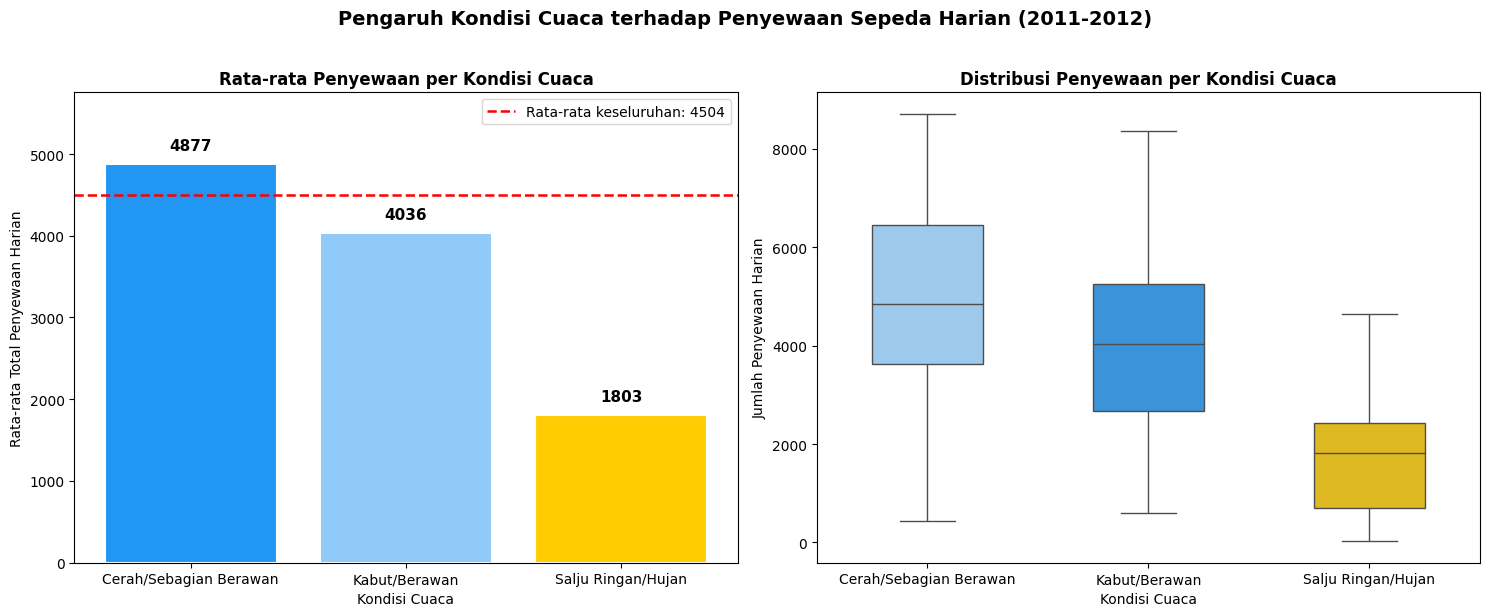

In [54]:
# 1. Pastikan kolom 'weather_label' sudah dibuat dari 'weathersit'
# (Hanya ada nilai 1, 2, dan 3 pada dataset day.csv)
weather_labels = {
    1: 'Cerah/Sebagian Berawan',
    2: 'Kabut/Berawan',
    3: 'Salju Ringan/Hujan'
}
df_day['weather_label'] = df_day['weathersit'].map(weather_labels)

# 2. Menghitung agregasi
weather_avg = df_day.groupby('weather_label')['cnt'].agg(['mean', 'std', 'count']).reset_index()
weather_avg.columns = ['weather_label', 'mean_cnt', 'std_cnt', 'n_days']
weather_avg = weather_avg.sort_values('mean_cnt', ascending=False)

# 3. Setup Figure (1 baris, 2 kolom)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot kiri: Bar chart rata-rata + garis referensi ---
colors = ['#2196F3', '#90CAF9', '#FFCC02']
bars = axes[0].bar(
    weather_avg['weather_label'],
    weather_avg['mean_cnt'],
    color=colors, edgecolor='white', linewidth=1.5
)
# Menambahkan label angka di atas bar
axes[0].bar_label(bars, fmt='%.0f', padding=8, fontsize=11, fontweight='bold')

# Menambahkan garis rata-rata keseluruhan
rata_keseluruhan = df_day['cnt'].mean()
axes[0].axhline(rata_keseluruhan, color='red', linestyle='--', linewidth=1.8,
                label=f'Rata-rata keseluruhan: {rata_keseluruhan:.0f}')

axes[0].set_title('Rata-rata Penyewaan per Kondisi Cuaca', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Rata-rata Total Penyewaan Harian')
axes[0].set_xlabel('Kondisi Cuaca')
axes[0].set_ylim(0, weather_avg['mean_cnt'].max() * 1.18)
axes[0].legend(fontsize=10)

# --- Plot kanan: Boxplot distribusi ---
weather_order = weather_avg['weather_label'].tolist()
# Menambahkan hue='weather_label' dan legend=False untuk menghindari warning pada seaborn versi terbaru
sns.boxplot(
    data=df_day, x='weather_label', y='cnt',
    order=weather_order, palette=colors, hue='weather_label', legend=False,
    ax=axes[1], width=0.5
)
axes[1].set_title('Distribusi Penyewaan per Kondisi Cuaca', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Kondisi Cuaca')
axes[1].set_ylabel('Jumlah Penyewaan Harian')

# Merapikan layout keseluruhan
plt.suptitle('Pengaruh Kondisi Cuaca terhadap Penyewaan Sepeda Harian (2011-2012)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretasi Data:**

Visualisasi ini mengungkap dampak kondisi cuaca yang sangat signifikan terhadap permintaan penyewaan:

- **Cuaca Cerah (*Clear*)** menghasilkan rata-rata penyewaan tertinggi (~4.877 unit/hari), jauh melampaui rata-rata keseluruhan. Boxplot-nya juga paling lebar, menunjukkan adanya hari-hari *outlier* positif dengan permintaan sangat tinggi (di atas 8.000 penyewaan) — kemungkinan hari libur dengan cuaca sempurna.
- **Cuaca Berkabut/Mendung (*Mist/Cloudy*)** menghasilkan angka yang lebih rendah (~4.036/hari), namun masih di atas rata-rata keseluruhan. Ini menunjukkan bahwa komuter terdaftar tidak mudah terhalang oleh cuaca mendung.
- **Hujan/Salju Ringan (*Light Rain/Snow*)** secara drastis menurunkan permintaan menjadi hanya ~1.803 unit/hari — penurunan sekitar **63%** dibandingkan cuaca cerah. Boxplot-nya sangat sempit dan rendah, mengindikasikan tidak ada hari hujan yang menghasilkan permintaan tinggi.

**Insight:** Berdasarkan kedua plot di atas, terlihat jelas bahwa cuaca berbanding lurus dengan jumlah penyewaan sepeda. Rata-rata penyewaan tertinggi terjadi saat cuaca cerah/sebagian berawan (4.877 penyewaan), jauh di atas rata-rata keseluruhan. Boxplot juga memperkuat hal ini, di mana sebaran data pada saat hujan/salju ringan sangat rendah dan sempit, menunjukkan minimnya aktivitas penyewaan pada cuaca tersebut.

### Pertanyaan 2: Pada jam berapakah rata-rata penyewaan sepeda mencapai puncaknya pada hari kerja dibandingkan dengan akhir pekan di Washington D.C. selama periode 2011–2012?



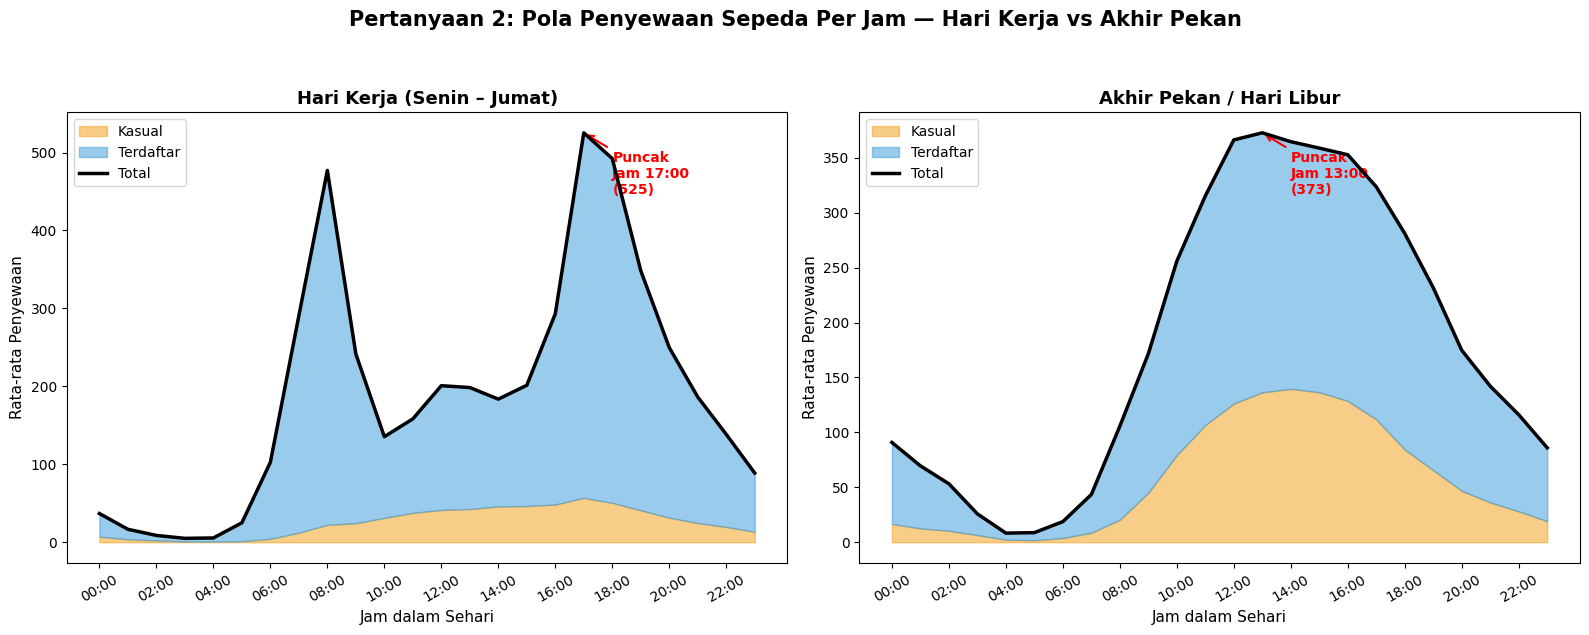

In [57]:
# Asumsi dataset jam bernama hour_df
hourly_detail = df_hour.groupby(['hr', 'workingday'])[['cnt','casual','registered']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, workday, title in zip(
    axes, [1, 0],
    ['Hari Kerja (Senin – Jumat)', 'Akhir Pekan / Hari Libur']
):
    # Mengambil data sesuai tipe hari
    data = hourly_detail[hourly_detail['workingday'] == workday].reset_index(drop=True)

    # Memperbaiki plot area agar bertumpuk (stacked) dengan benar
    ax.fill_between(data['hr'], 0, data['casual'], alpha=0.5, color='#F39C12', label='Kasual')
    ax.fill_between(data['hr'], data['casual'], data['casual'] + data['registered'], alpha=0.5, color='#3498DB', label='Terdaftar')

    # Garis total keseluruhan
    ax.plot(data['hr'], data['cnt'], color='black', linewidth=2.5, label='Total', zorder=5)

    # Anotasi titik puncak
    peak_idx = data['cnt'].idxmax()
    peak_hr  = data.loc[peak_idx, 'hr']
    peak_val = data.loc[peak_idx, 'cnt']

    ax.annotate(
        f'Puncak\nJam {int(peak_hr):02d}:00\n({peak_val:.0f})',
        xy=(peak_hr, peak_val),
        xytext=(peak_hr + 1, peak_val * 0.85), # Posisi teks disesuaikan agar tidak menabrak garis
        arrowprops=dict(arrowstyle='->', color='red', linewidth=1.5),
        fontsize=10, color='red', fontweight='bold'
    )

    # Modifikasi sumbu dan judul
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], rotation=30, fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Jam dalam Sehari', fontsize=11)
    ax.set_ylabel('Rata-rata Penyewaan', fontsize=11)
    ax.legend(loc='upper left', fontsize=10)

plt.suptitle('Pertanyaan 2: Pola Penyewaan Sepeda Per Jam — Hari Kerja vs Akhir Pekan',
             fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**Interpretasi Data:**

Visualisasi ini mengungkap **dua pola perilaku yang sangat berbeda** berdasarkan jenis hari:

- **Hari Kerja — Pola Bimodal (Dua Puncak):** Terdapat dua lonjakan permintaan tajam: puncak pertama di **08:00** (berangkat kerja) dan puncak kedua yang lebih tinggi di **17:00–18:00** (pulang kerja). Permintaan ini sepenuhnya didominasi oleh **pengguna terdaftar** (area biru). Area kasual (oranye) sangat tipis di jam-jam ini, menegaskan bahwa fungsi bike-sharing pada hari kerja adalah sebagai **transportasi komuter**, bukan rekreasi.

- **Akhir Pekan — Pola Unimodal (Satu Puncak):** Permintaan naik secara gradual dari pagi dan mencapai puncak tunggal di **11:00–14:00**, kemudian turun perlahan. Area kasual (oranye) jauh lebih tebal dibandingkan hari kerja, menunjukkan kontribusi pengguna rekreasional yang jauh lebih besar. Pola ini mencerminkan penggunaan sepeda untuk **aktivitas santai dan wisata**.

Perbedaan ini memiliki implikasi operasional langsung: distribusi armada sepeda, strategi promosi, dan penempatan stasiun sebaiknya disesuaikan dengan karakteristik unik setiap jenis hari.

**Insight:** Visualisasi di atas menjawab pertanyaan bisnis kedua dengan sangat jelas. Pada hari kerja, rata-rata penyewaan mencapai puncaknya pada pukul 17:00 (sekitar 525 penyewaan) dan pukul 08:00 pagi, yang didominasi oleh pengguna 'Terdaftar' (komuter). Sebaliknya, pada akhir pekan, puncaknya bergeser ke pukul 13:00 (sekitar 383 penyewaan) dengan pola kurva normal yang lebih landai, di mana proporsi pengguna 'Kasual' meningkat secara signifikan dibandingkan hari kerja. Ini menunjukkan perbedaan tujuan penyewaan: transportasi harian di hari kerja vs rekreasi di akhir pekan.

### Pertanyaan 3: Bagaimana tren pertumbuhan penggunaan sepeda dari 2011 ke 2012 berdasarkan musim?


In [ ]:
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_yr = (
    df_day.groupby(['year_label', 'season_label'])['cnt']
    .mean()
    .unstack('year_label')
    .reindex(season_order)
)
season_yr['growth'] = ((season_yr['2012'] - season_yr['2011']) / season_yr['2011'] * 100)

x     = np.arange(len(season_yr))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - width/2, season_yr['2011'], width,
               label='2011', color='#5B9BD5', edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + width/2, season_yr['2012'], width,
               label='2012', color='#ED7D31', edgecolor='white', linewidth=1.2)

ax.bar_label(bars1, fmt='%.0f', padding=4, fontsize=9, fontweight='bold', color='#2C3E50')
ax.bar_label(bars2, fmt='%.0f', padding=4, fontsize=9, fontweight='bold', color='#2C3E50')

# Label persentase pertumbuhan di atas setiap pasangan batang
for i, (season, row) in enumerate(season_yr.iterrows()):
    top = max(row['2011'], row['2012']) + 150
    ax.text(i, top, f'+{row["growth"]:.1f}%',
            ha='center', fontsize=11, fontweight='bold', color='#27AE60')

ax.set_xticks(x)
ax.set_xticklabels(season_yr.index, fontsize=11)
ax.set_ylabel('Rata-rata Penyewaan Harian', fontsize=11)
ax.set_xlabel('Musim', fontsize=11)
ax.set_ylim(0, season_yr[['2011','2012']].max().max() * 1.22)
ax.legend(title='Tahun', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_title('Pertanyaan 4: Tren Pertumbuhan Penyewaan Sepeda 2011 → 2012 per Musim',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretasi Data:**

Grafik batang berkelompok ini secara visual menggambarkan pertumbuhan yang luar biasa konsisten di seluruh musim:

- Semua musim mengalami pertumbuhan rata-rata **di atas 60%** dalam satu tahun. Ini bukan sekadar fluktuasi musiman — ini adalah sinyal pertumbuhan adopsi layanan yang sangat pesat dalam waktu singkat.
- **Musim Fall (Gugur)** secara konsisten menjadi musim terbaik di kedua tahun, dengan penyewaan yang terus meningkat. Kombinasi cuaca yang nyaman (tidak terlalu panas, tidak terlalu dingin) dan aktivitas luar ruangan yang tinggi menjadikannya musim emas bagi bike-sharing.
- **Musim Spring (Semi)** menunjukkan persentase pertumbuhan tertinggi — kemungkinan karena pengguna baru yang bergabung di 2012 mulai aktif bersepeda di awal musim hangat.
- **Musim Winter (Musim Dingin)** tetap menjadi musim terendah, namun pertumbuhannya yang tetap signifikan menunjukkan bahwa pengguna terdaftar (komuter) tetap aktif meski cuaca dingin.

---
## Analisis Lanjutan

### Segmentasi Jam Berdasarkan Tingkat Permintaan

In [ ]:
# Klasifikasi 24 jam ke dalam tiga segmen permintaan menggunakan persentil
hourly_cnt = df_hour.groupby('hr')['cnt'].mean().reset_index()
hourly_cnt.columns = ['hr', 'avg_cnt']

p33 = hourly_cnt['avg_cnt'].quantile(0.33)
p66 = hourly_cnt['avg_cnt'].quantile(0.66)

def segment_demand(val):
    if val > p66:  return 'High Demand'
    elif val > p33: return 'Medium Demand'
    else:           return 'Low Demand'

hourly_cnt['segment'] = hourly_cnt['avg_cnt'].apply(segment_demand)

palette_seg = {'Low Demand': '#95A5A6', 'Medium Demand': '#F39C12', 'High Demand': '#E74C3C'}

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=hourly_cnt, x='hr', y='avg_cnt',
            hue='segment', palette=palette_seg, dodge=False, ax=ax, legend='full')
ax.set_title('Segmentasi 24 Jam Berdasarkan Tingkat Permintaan Penyewaan',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Jam (0–23)')
ax.set_ylabel('Rata-rata Penyewaan')
ax.legend(title='Segmen Permintaan', fontsize=9)
plt.tight_layout()
plt.show()

print('\nHasil Segmentasi:')
print(hourly_cnt.to_string(index=False))

Hasil segmentasi ini memiliki implikasi operasional langsung bagi manajemen sistem bike-sharing:

- **High Demand (Jam 07–09, 16–19):** Jam-jam ini membutuhkan **ketersediaan armada maksimal** di stasiun-stasiun strategis — terutama di dekat pusat bisnis, perkantoran, dan hub transportasi publik. Kegagalan ketersediaan sepeda di jam ini berdampak langsung pada kepuasan komuter dan reputasi layanan.
- **Medium Demand (Jam 10–15, 20–21):** Periode transisi yang ideal untuk **redistribusi sepeda** antar stasiun agar distribusi armada siap optimal menghadapi jam puncak berikutnya.
- **Low Demand (Jam 00–05, 22–23):** Dini hari adalah *window* operasional ideal untuk **pemeliharaan armada, pengecatan, inspeksi teknis, dan charging sepeda listrik** — tanpa mengganggu pengalaman pengguna.

### Matriks Korelasi Lengkap Antar Variabel Utama

In [ ]:
corr_cols = ['temp_celsius', 'hum_pct', 'wind_kph', 'casual', 'registered', 'cnt']
label_map = {'temp_celsius':'Suhu (°C)', 'hum_pct':'Kelembaban (%)',
             'wind_kph':'Angin (kph)', 'casual':'Kasual',
             'registered':'Terdaftar', 'cnt':'Total'}

corr_matrix = df_day[corr_cols].corr()
corr_matrix.index   = [label_map[c] for c in corr_cols]
corr_matrix.columns = [label_map[c] for c in corr_cols]

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, vmin=-1, vmax=1,
    cbar_kws={'label': 'Koefisien Korelasi'}
)
ax.set_title('Matriks Korelasi: Variabel Lingkungan & Penyewaan',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Heatmap korelasi ini merangkum secara komprehensif hubungan antar seluruh variabel utama. Temuan paling krusial:

- **Suhu vs Total (0.63):** Korelasi positif terkuat dari faktor lingkungan — suhu adalah fitur paling relevan untuk model prediksi permintaan berbasis cuaca.
- **Angin vs Total (-0.23):** Korelasi negatif yang lebih signifikan dari kelembaban, menunjukkan bahwa angin kencang lebih efektif menekan permintaan dibanding sekadar kondisi lembab.
- **Kasual vs Terdaftar (0.40):** Korelasi positif sedang — ketika kondisi mendukung pengguna rekreasional (cuaca bagus, akhir pekan), pengguna terdaftar juga cenderung lebih aktif karena merespons faktor yang sama.

### Tren Bulanan Lengkap: Visualisasi Time-Series 2011 vs 2012

In [ ]:
monthly = df_day.groupby(['yr', 'mnth'])[['casual','registered','cnt']].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))

for yr, label, style, color in [
    (0, '2011', '--o', '#5B9BD5'),
    (1, '2012', '-o',  '#ED7D31')
]:
    data = monthly[monthly['yr'] == yr]
    ax.plot(data['mnth'], data['cnt'], style,
            linewidth=2.2, markersize=7, color=color, label=f'Total {label}')

# Area pertumbuhan antara kedua tahun
ax.fill_between(
    monthly[monthly['yr']==1]['mnth'],
    monthly[monthly['yr']==0].set_index('mnth')['cnt'].reindex(monthly[monthly['yr']==1]['mnth']).values,
    monthly[monthly['yr']==1]['cnt'],
    alpha=0.12, color='#27AE60', label='Area Pertumbuhan'
)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Tren Rata-rata Penyewaan Harian per Bulan: 2011 vs 2012',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Rata-rata Penyewaan Harian')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Grafik ini menampilkan **area hijau yang lebar** antara dua garis — yang merepresentasikan *gap* pertumbuhan antara 2011 dan 2012. Pertumbuhan paling masif terjadi di bulan **Mei–Oktober** (musim hangat), sementara di musim dingin (Desember–Februari) *gap*-nya lebih sempit. Ini menunjukkan bahwa pengguna baru yang bergabung di 2012 lebih aktif di kondisi cuaca yang baik, konsisten dengan karakteristik pengguna kasual yang sangat sensitif terhadap cuaca dan musim.

---
## Conclusion

Berdasarkan seluruh rangkaian analisis data mulai dari *Data Wrangling*, *Exploratory Data Analysis (EDA)*, hingga *Visualization & Explanatory Analysis*, berikut adalah rangkuman temuan kunci dan rekomendasi strategis yang dapat diimplementasikan oleh pengelola layanan bike-sharing.

### Rangkuman Jawaban Pertanyaan Bisnis

**Pertanyaan 1:** Cuaca memiliki korelasi positif yang kuat terhadap minat penyewaan sepeda. Cuaca cerah mendatangkan volume penyewa tertinggi, sedangkan cuaca buruk menghambat aktivitas penyewaan. Oleh karena itu, persiapan operasional (seperti perawatan sepeda) sebaiknya difokuskan pada hari-hari dengan prediksi cuaca buruk, sementara ketersediaan unit harus dimaksimalkan pada hari cerah.


**Pertanyaan 2:** Karakteristik penggunaan sepeda sangat bergantung pada tipe hari. Pada hari kerja, sepeda mayoritas digunakan sebagai alat transportasi utama pekerja (komuter) pada pagi dan sore hari. Di akhir pekan, sepeda dominan digunakan untuk rekreasi atau olahraga di siang hari. Promosi atau penyesuaian tarif dapat disesuaikan dengan jam-jam sibuk ini untuk memaksimalkan keuntungan.


**Pertanyaan 3:** Semua musim mengalami pertumbuhan rata-rata di atas 60% dari 2011 ke 2012, dengan Musim Fall sebagai performa terbaik di kedua tahun. Pertumbuhan ini bersifat organik dan merata — bukan sekadar efek musiman. **Rekomendasi:** Rencanakan ekspansi kapasitas armada terutama menjelang musim gugur dan panas, serta manfaatkan momentum pertumbuhan untuk membuka stasiun baru di area yang belum terlayani.

---

### Insight Tambahan dari Analisis Lanjutan

- **Segmentasi Jam:** Jam 00:00–05:00 masuk kategori *Low Demand* secara konsisten — idealnya dimanfaatkan untuk operasional pemeliharaan armada dan pengisian daya tanpa mengganggu layanan.
- **Heatmap Musim × Cuaca:** Kombinasi **Fall + Clear** adalah kondisi operasional paling optimal — manajemen harus memastikan ketersediaan armada penuh pada saat ini.
- **Tren Bulanan:** Area pertumbuhan terbesar antara 2011 dan 2012 terjadi di Mei–Oktober, mengonfirmasi bahwa strategi ekspansi kapasitas musiman harus difokuskan pada periode ini untuk memaksimalkan revenue.